# (22) Rot MNIST: w/ zeta

host = ```chewie```, device = ```cuda:1```

**Motivation**:  <br>

- $\Delta \theta = 4.0$
- $T_\text{train} = 16$
- $T_\text{tbptt} = 16$

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST+rotate', model_type, 'ngd|lin')

cfg_vae['t_train'] = 16
cfg_vae['t_tbptt'] = 16
cfg_vae['kl_beta'] = 1.0

cfg_vae['latent_channels'] = 128
cfg_vae['latent_pixels'] = 8
cfg_vae['latent_stride'] = 3

cfg_vae['fwd_ker_zeta'] = 8

cfg_vae['feeder_cfg'] = {'delta_theta': 4.0}
cfg_vae['clamp_vals'] = {'u': (4.0,), 'du': (4.0,), 'dec': 2.3}

cfg_vae['recon_mode'] = 'mse'
cfg_vae['fit_sigma'] = True
cfg_vae['fit_dt'] = True

cfg_tr['lr'] = 1e-3
cfg_tr['epochs'] = 200
cfg_tr['batch_size'] = 400
# cfg_tr['grad_clip'] = 3000
# cfg_tr['kl_const_portion'] = 0.0
# cfg_tr['kl_anneal_portion'] = 0.0

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

30000

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  2.1 Mil   |
|     ———     |    ———     |
|    layer    |  2.1 Mil   |
+-------------+------------+

poisson_MNIST+rotate_t-(16,16)_b-1_kms-(128,8,3)_fwd-(1,8)_<ngd|lin>
b400-ep200-lr(0.001)_temp(0.05)_gr(150)_(2025_08_22,12:02)

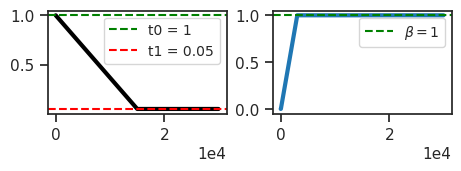

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
print(f"{tr.model.layer} \n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(128, 8, 8), input_sz=(1, 28, 28), temp=1) 
ConvDictionary(in_channels=128, out_channels=1, kernel_size=7, stride=3)

In [8]:
print_num_params(tr.model.layer)

+---------------+------------+
|  Module Name  | Num Params |
+---------------+------------+
|  PoissonLayer |  2.1 Mil   |
|      ———      |    ———     |
|     log_dt    |     1      |
|      dec      |   6.3 K    |
|    fwd_z.0    |   16.4 K   |
|  zeta_pool.0  |  1.1 Mil   |
| zeta_expand.0 |  1.1 Mil   |
|     u_init    |    128     |
+---------------+------------+

In [9]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 't_train': 16, 't_tbptt': 16, 'kl_beta': 1.0, 'latent_channels': 
128, 'latent_pixels': 8, 'latent_stride': 3, 'fwd_ker_z': 1, 'fwd_ker_zeta': 8, 'enc_type': 'ngd', 'dec_type': 
'lin', 'recon_mode': 'mse', 'dataset': 'MNIST+rotate', 'dataset_name': 'MNIST', 'feeder': 'rotate', 'feeder_cfg': 
{'delta_theta': 4.0, 'theta_0': None}, 'input_sz': (1, 28, 28), 'latent_sz': (128, 8, 8), 'init_dist': 'normal', 
'init_scale': 0.0001, 'clamp_vals': {'u': (4.0,), 'du': (4.0,), 'dec': 2.3}, 'stochastic': True, 'optim_sigma': 
False, 'fit_sigma': True, 'fit_prior': True, 'fit_dt': True, 'seed': 0, 'track_stats': False, 'base_dir': 
'/home/hadi/Projects/TemporalSC', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/TemporalSC/runs/poisson_MNIST+rotate_t-(16,16)_b-1_kms-(128,8,3)_fwd-(1,8)_<ngd|lin>', 
'mods_dir': 
'/home/hadi/Projects/TemporalSC/models/poisson_MNIST+rotate_t-(16,16)_b-1_kms-(128,8,3)_fwd-(1,8)_<ngd|lin>', 
'results_dir': '/home/hadi/Projects/TemporalSC/results'}

{'lr': 0.001, 'epochs': 200, 'batch_size': 400, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 199.0, 'eta_min': 1e-06}, 'ema_rate': None, 'grad_clip': 
150, 'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [10]:
tr.train('fwd:1,8-fit:dt+sigma')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 200, avg loss: 15.507: 100%|███████| 200/200 [6:08:35<00:00, 110.58s/it]


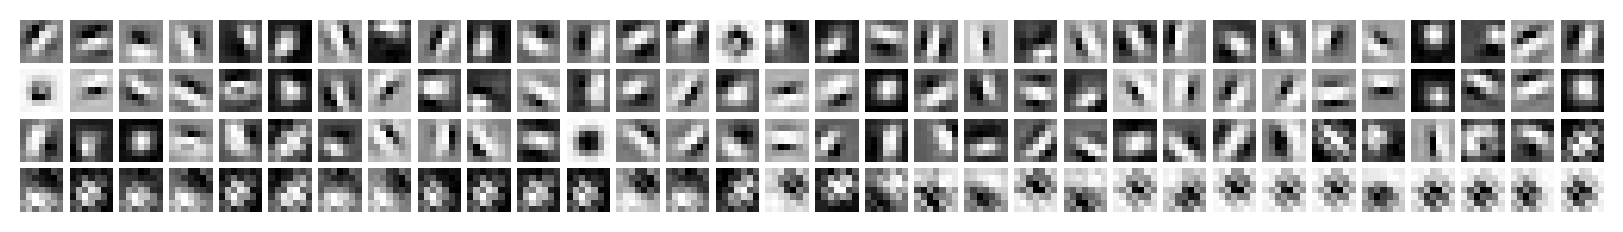

In [11]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [12]:
output = tr.xtract_ftr(
    data='vld',
    t_total=32,
    save_freq=1,
    data_batch_sz=50,
    n_data_batches=1,
    return_recon=True,
    verbose=False,
)

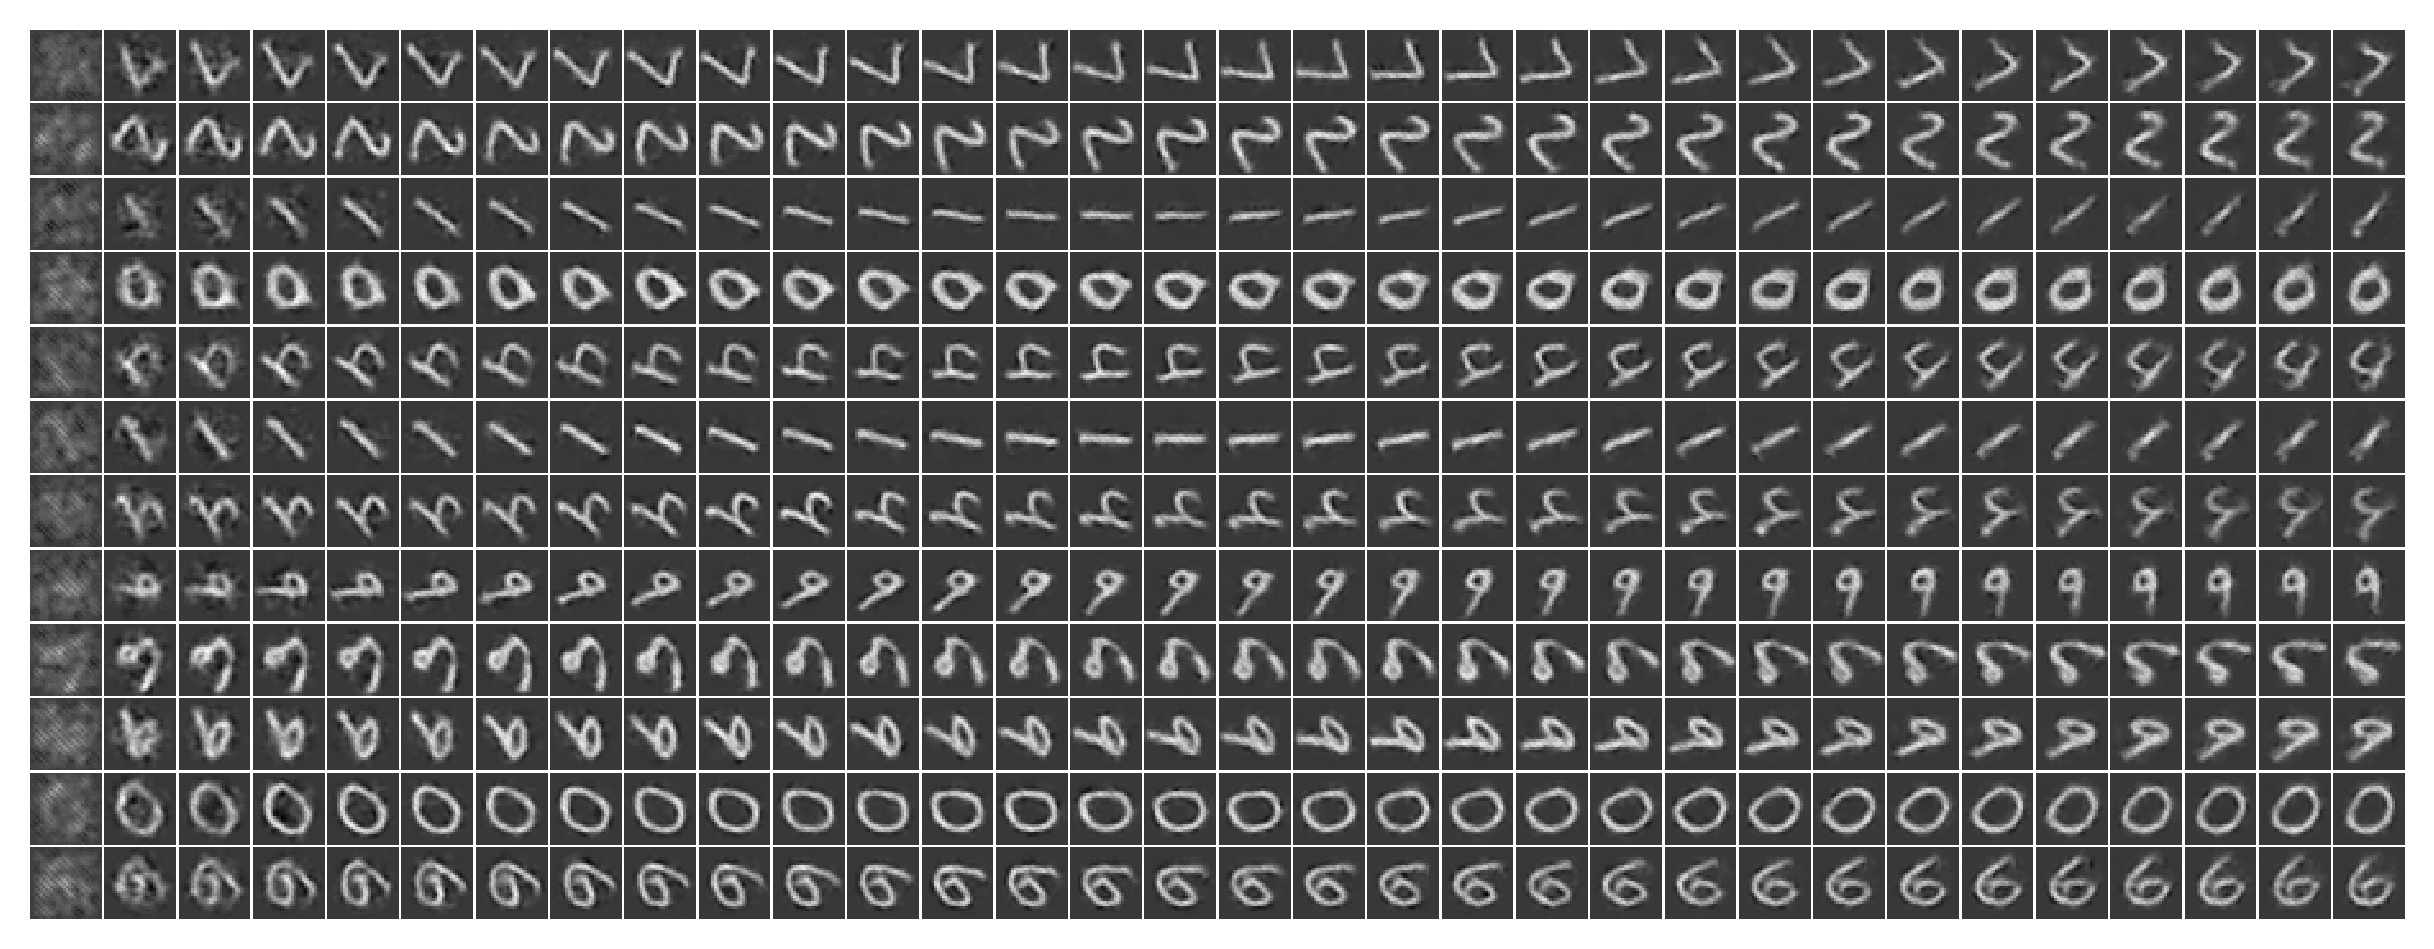

In [13]:
num = 12
x2p = output['recon'][:num].reshape(-1, 28, 28)
_ = plot_weights(x2p, method='none', nrows=num, dpi=300)

100%|███████████████████████████████████| 5/5 [00:16<00:00,  3.29s/it]


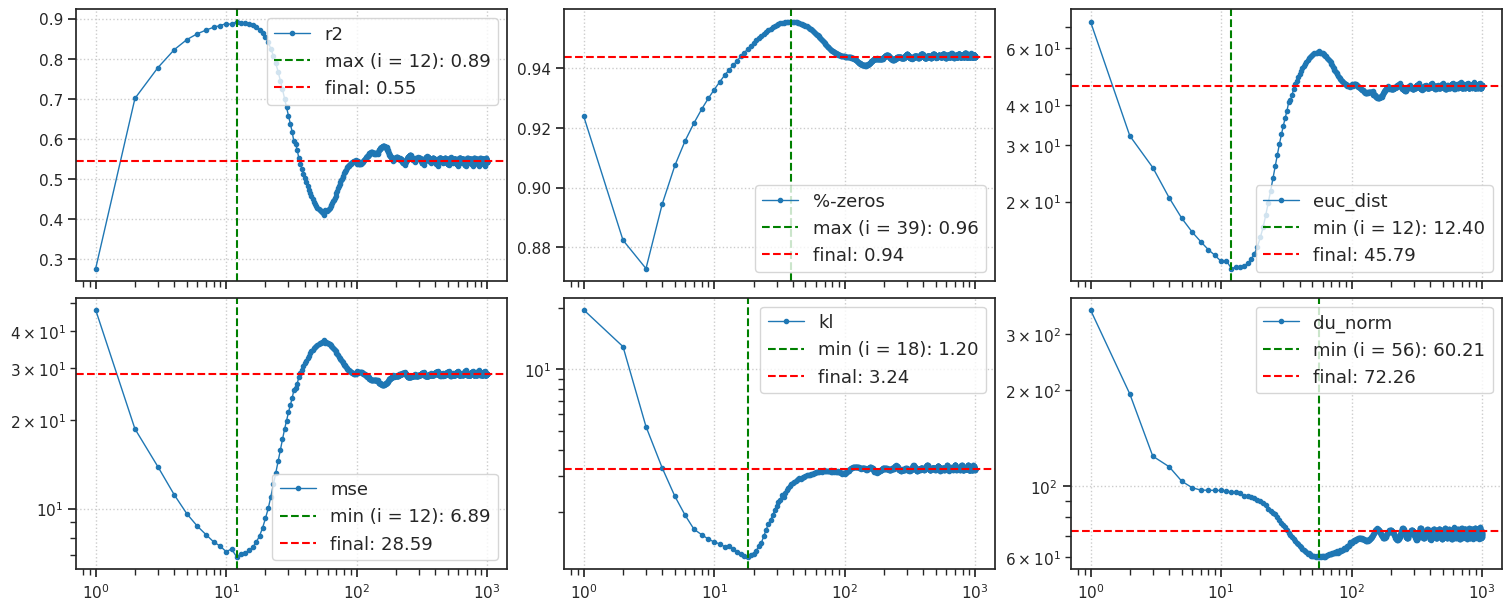

CPU times: user 17.5 s, sys: 8.49 ms, total: 17.5 s
Wall time: 17.5 s


In [14]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=5)
_ = plot_convergence(results=results, color='C0')

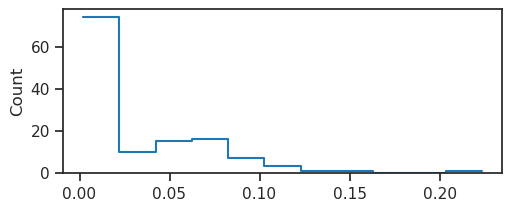

In [15]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)

fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

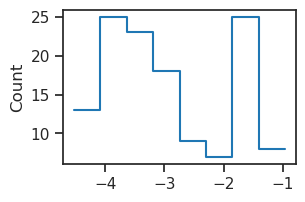

In [16]:
histplot(u0.ravel())
plt.show()

In [17]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=0.6314796, pvalue=1.3343739045578666e-15)

In [18]:
output = tr.xtract_ftr(
    data='vld',
    t_total=1000,
    save_freq=1,
    data_batch_sz=10,
    n_data_batches=1,
    return_recon=True,
    verbose=False,
)

In [19]:
from utils.animation import show_movie

show_movie(output['recon'][0].squeeze(), max_n=-1, figsize=(3.5, 2.0))

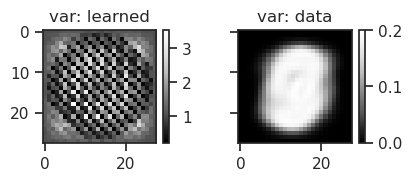

learned inner learning rates (dt):

(tensor([2.6762], device='cuda:1', grad_fn=<ExpBackward0>),)

In [20]:
# get var: learned & data
log_sigma = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_sigma) ** 2).reshape(tr.model.cfg.input_sz)
var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0))

# plot
fig, axes =  create_figure(1, 2, (4.2, 1.7), sharex='all', sharey='all')
im = axes[0].imshow(var_learned.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

axes[0].set_title('var: learned')
axes[1].set_title('var: data')

plt.show()

# print dt
lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
print(f"learned inner learning rates (dt):\n\n{lr_inner}\n")